# Semester Project
## Alicia Mann 
### BCIS 566- U70
### May 6, 2026

In [1]:
#If this is your first time running the notebook, 
#you will needed to remove the "#" and install the UCI repository

#pip install ucimlrepo

In [2]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.preprocessing import LabelBinarizer
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  confusion_matrix, accuracy_score, precision_score, recall_score



/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 

# 1. Exploratory Data Analysis

## 1.1 Overview of Dataset

In [4]:
#display short discription of dataset
bike_sharing.metadata.abstract

'This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.'

In [5]:
#access and assign full dataset as a dataframe
bike_df = bike_sharing.data.original

In [6]:
bike_df.head() #view first five rows of entire dataset

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [7]:
bike_df.shape #view the dataframe dimensions (number of rows and columns)

(17379, 17)

In [8]:
#review information about the variables of the dataset
#review keys for categorical variables

print(bike_sharing.metadata.additional_info.variable_info)

Both hour.csv and day.csv have the following fields, except hr which is not available in day.csv
	
	- instant: record index
	- dteday : date
	- season : season (1:winter, 2:spring, 3:summer, 4:fall)
	- yr : year (0: 2011, 1:2012)
	- mnth : month ( 1 to 12)
	- hr : hour (0 to 23)
	- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
	- weekday : day of the week
	- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
	+ weathersit : 
		- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
		- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
		- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
		- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
	- temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
	- atemp: Normalized feeling temperature in Celsius. The values are deriv

In [9]:
#review data types of columns
bike_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [10]:
#review data to see if there are any missing values
bike_sharing.variables.missing_values

0     no
1     no
2     no
3     no
4     no
5     no
6     no
7     no
8     no
9     no
10    no
11    no
12    no
13    no
14    no
15    no
16    no
Name: missing_values, dtype: object

In [11]:
# data (as pandas dataframes) 
#features dataframe does not included instant (the ID variable), casual, and registered <users>
X = bike_sharing.data.features 
y = bike_sharing.data.targets 

In [12]:
X.head() #view first five rows of feature columns

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0


In [13]:
#generate some descriptive statisics of the numerical features
bike_df[['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']].describe()

,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## 1.2 Examination of Variables

## 1.2.1 Date/Time Variables

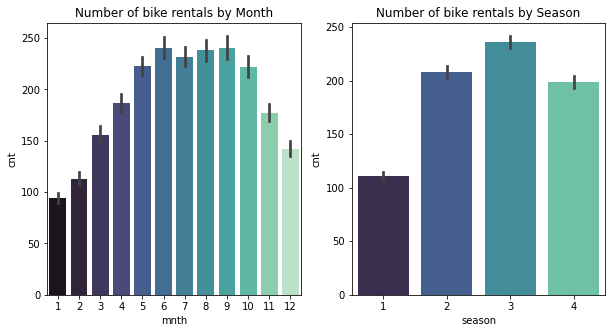

Season key- 1:winter, 2:spring, 3:summer, 4:fall


In [14]:
fig,(p1,p2) = plt.subplots(ncols=2, figsize= (10,5))
sns.barplot(data=bike_df, x="mnth", y="cnt", ax=p1, palette="mako")
p1.set(title="Number of bike rentals by Month")
sns.barplot(x="season", y="cnt", data= bike_df, ax=p2, palette="mako")
p2.set(title="Number of bike rentals by Season")
plt.show()
print("Season key- 1:winter, 2:spring, 3:summer, 4:fall")

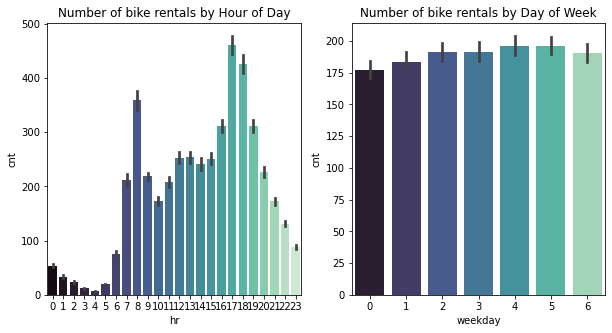

In [15]:
fig,(p1,p2) = plt.subplots(ncols=2, figsize= (10,5))
sns.barplot(data=bike_df, x="hr", y="cnt",  ax = p1, palette="mako")
p1.set(title="Number of bike rentals by Hour of Day")
sns.barplot(data=bike_df, x="weekday", y= "cnt", ax = p2, palette="mako")
p2.set(title="Number of bike rentals by Day of Week")

plt.show()

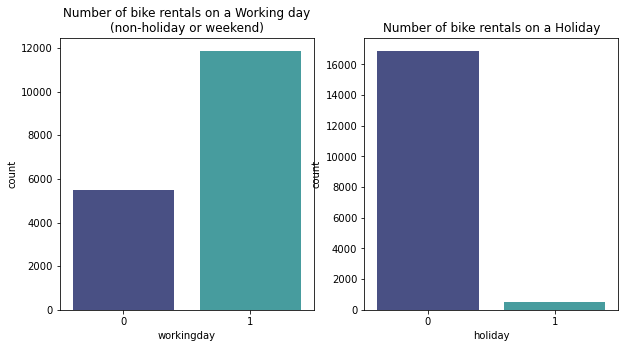

In [16]:
fig, (p1,p2) = plt.subplots(ncols=2, figsize=(10, 5))
sns.countplot(data=bike_df, x="workingday", ax=p1, palette="mako")
p1.set(title = "Number of bike rentals on a Working day\n(non-holiday or weekend)")
sns.countplot(data=bike_df, x="holiday", ax=p2, palette="mako")
p2.set(title = "Number of bike rentals on a Holiday")

plt.show()

## 1.2.2 Weather/Temperature Varables 

/opt/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


[Text(0.5, 1.0, 'Number of bike rentals by Temperature\n(feeling)')]

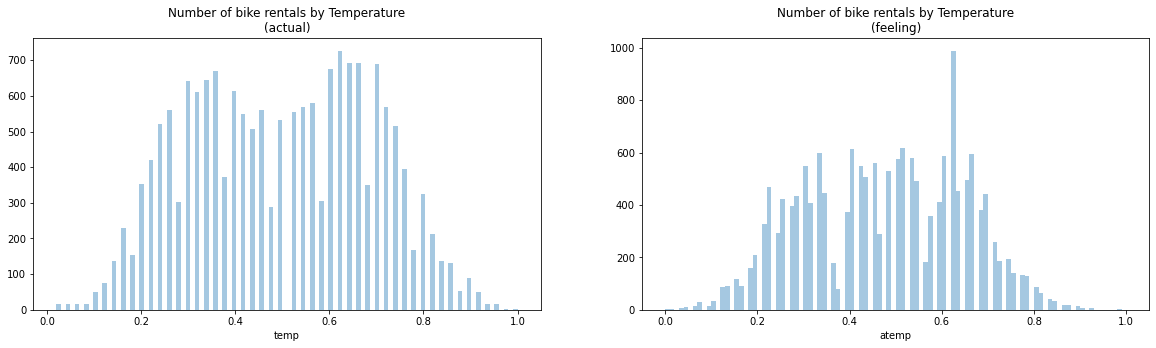

In [17]:
fig, (p1,p2) = plt.subplots(ncols=2, figsize=(20, 5))
sns.distplot(bike_df["temp"], kde=False, bins= 100, ax=p1)
p1.set(title = "Number of bike rentals by Temperature\n(actual)")
sns.distplot(bike_df["atemp"], kde=False, bins= 100, ax=p2)
p2.set(title = "Number of bike rentals by Temperature\n(feeling)")

[Text(0.5, 1.0, 'Number of bike rentals by Windspeed')]

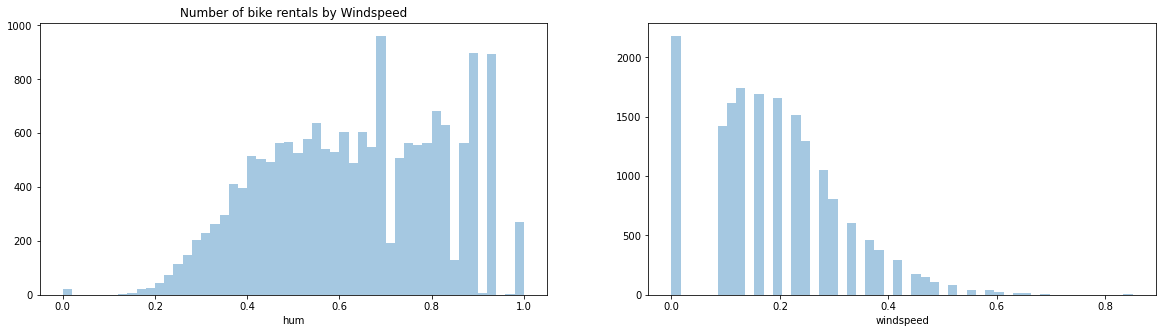

In [18]:
fig, (p1,p2) = plt.subplots(ncols=2, figsize=(20, 5))
sns.distplot(bike_df["hum"], kde=False, bins= 50, ax=p1)
p1.set(title = "Number of bike rentals by Humidity")
sns.distplot(bike_df["windspeed"], kde=False, bins= 50, ax=p2)
p1.set(title = "Number of bike rentals by Windspeed")

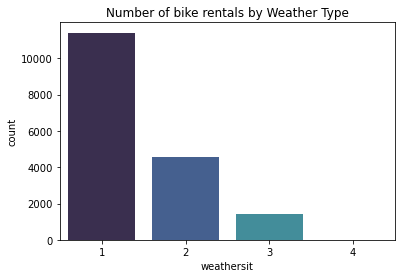

Weather Type Key- 
1: Clear, Few clouds, Partly cloudy, Partly cloudy
2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog


In [19]:
p = sns.countplot(data=bike_df, x="weathersit", palette="mako")
p.set(title="Number of bike rentals by Weather Type")
plt.show()
print("Weather Type Key- \n1: Clear, Few clouds, Partly cloudy, Partly cloudy\n2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist\n3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds\n4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog")

## 1.2.3 User/Customer Variables

In [20]:
sum_df = bike_df[['casual', 'registered']].sum()
print(sum_df)

casual         620017
registered    2672662
dtype: int64


[Text(0.5, 1.0, 'Number of Users by Type')]

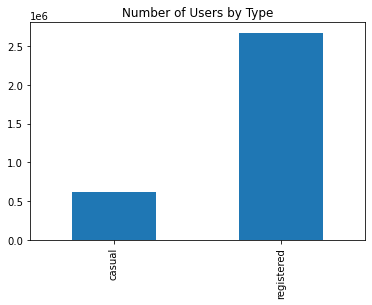

In [21]:
p = sum_df.plot(x=["casual", "registered"], kind ="bar")
p.set(title="Number of Users by Type")

# 2. Data Preprocessing

In [22]:
X = bike_sharing.data.features #Drop unnecessary columns from the features dataset
X = X.drop(columns=["dteday"])

<AxesSubplot:>

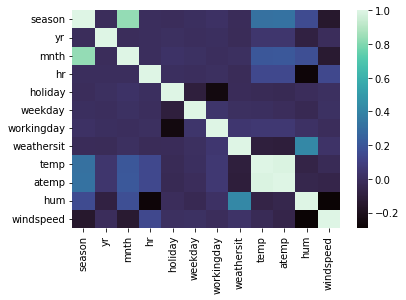

In [23]:
sns.heatmap(X.corr(), cmap="mako") #Create a correlation heatmap

In [24]:
#From the heat map we can see that season and month, and temp and atemp
#are highly correlated. It appears prudent to drop these columns for
#their more specific counterparts to reduce redundancy
X = X.drop(columns=["yr", "season", "atemp"])

In [25]:
# Initialize and fit a random forest classifier
bike_rfModel = RandomForestRegressor(n_estimators=200, max_features=5, min_samples_split=4)
bike_rfModel.fit(X, np.ravel(y))

RandomForestRegressor(max_features=5, min_samples_split=4, n_estimators=200)

In [26]:
# Variable importance table
pd.DataFrame(
    data={
        "feature": bike_rfModel.feature_names_in_,
        "importance": bike_rfModel.feature_importances_,
    }
).sort_values("importance", ascending=False)

,feature,importance
1,hr,0.562877
6,temp,0.157804
7,hum,0.084117
4,workingday,0.053065
0,mnth,0.049781
3,weekday,0.034659
8,windspeed,0.033699
5,weathersit,0.020836
2,holiday,0.003162


Text(0.5, 1.5, 'Day')

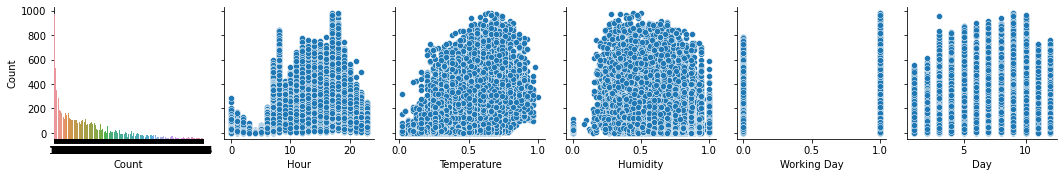

In [27]:
# Examine relationships between top 5 features and rental count
x_vars = ["cnt", "hr", "temp", "hum", "workingday", "mnth"]
y_vars = ["cnt"]
g = sns.PairGrid(bike_df, x_vars=x_vars, y_vars=y_vars)
g.map_diag(sns.countplot)
g.map_offdiag(sns.scatterplot)

g.axes[0][0].set_xlabel("Count")
g.axes[0][0].set_ylabel("Count")
g.axes[0][1].set_xlabel("Hour")
g.axes[0][2].set_xlabel("Temperature")
g.axes[0][3].set_xlabel("Humidity")
g.axes[0][4].set_xlabel("Working Day")
g.axes[0][5].set_xlabel("Day")

In [28]:
#create training/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.10)

#Scale input features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
#initial initialization on k-nearest nieghbor model
bike_knn_pre = KNeighborsRegressor()
#create a tuning grid for potential number of neighbors
k = {"n_neighbors":[3, 5, 7, 9, 11]}

#initialize grid search
knn_tuning = GridSearchCV(bike_knn_pre, k)
knn_tuning.fit(X_train, np.ravel(y_train))

GridSearchCV(estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11]})

In [30]:
#Display the results
print("Average Testing Scores: ", knn_tuning.cv_results_["mean_test_score"].round(3))
print("Best Estimator: ", knn_tuning.best_estimator_)

Average Testing Scores:  [0.619 0.634 0.632 0.627 0.622]
Best Estimator:  KNeighborsRegressor()


In [31]:
# initial initialization on random forest model
bike_RF_pre = RandomForestRegressor()
#create a tuning grid for potential number of decision trees
k = {"min_samples_split": [2,3,4], "max_features": [2,3,4,5]}

#initialize grid search
RF_tuning = GridSearchCV(bike_RF_pre, k)
RF_tuning.fit(X_train, np.ravel(y_train))

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_features': [2, 3, 4, 5],
                         'min_samples_split': [2, 3, 4]})

In [32]:
#Display the results
print("Average Testing Scores: ", RF_tuning.cv_results_["mean_test_score"].round(3))
print("Best Estimator: ", RF_tuning.best_estimator_)

Average Testing Scores:  [0.83  0.826 0.824 0.856 0.852 0.851 0.863 0.862 0.862 0.864 0.864 0.862]
Best Estimator:  RandomForestRegressor(max_features=5, min_samples_split=3)


In [33]:
#Define the models with optimal parameters
bike_LR = LinearRegression()
bike_knn = KNeighborsRegressor(n_neighbors=7)
bike_RF = RandomForestRegressor(n_estimators=200, max_features=5, min_samples_split=3)

In [34]:
# Define a set of cross-validation folds
kf = KFold(n_splits=10, random_state=42, shuffle=True)

In [35]:
#Fit linear regression model w/ cross-validation
LR_prediction = cross_validate(bike_LR, X_train, np.ravel(y_train), cv=kf)
LR_scores = LR_prediction["test_score"]
print("Linear Regression Validation Score: ", LR_scores.round(3))
print("Average: ", LR_scores.mean().round(3))

Linear Regression Validation Score:  [0.344 0.332 0.317 0.363 0.349 0.314 0.296 0.335 0.313 0.327]
Average:  0.329


In [36]:
#Fit K-nearest neighbor regression model w/ cross-validation
KNN_prediction = cross_validate(bike_knn, X_train, np.ravel(y_train), cv=kf)
KNN_scores = KNN_prediction["test_score"]
print("KNN Validation Score: ", KNN_scores.round(3))
print("Average: ", KNN_scores.mean().round(3))

KNN Validation Score:  [0.668 0.644 0.623 0.654 0.66  0.652 0.598 0.649 0.647 0.639]
Average:  0.644


In [37]:
#Fit Random Forest model w/ cross-validation
RF_prediction = cross_validate(bike_RF, X_train, np.ravel(y_train), cv=kf)
RF_scores = RF_prediction["test_score"]
print("Random Forest Validation Score: ", RF_scores.round(3))
print("Average: ", RF_scores.mean().round(3))

Random Forest Validation Score:  [0.872 0.87  0.874 0.857 0.879 0.86  0.873 0.864 0.867 0.873]
Average:  0.869


In [38]:
#Examine model performance on test data
bike_LR.fit(X_train, np.ravel(y_train))
bike_knn.fit(X_train, np.ravel(y_train))
bike_RF.fit(X_train, np.ravel(y_train))

RandomForestRegressor(max_features=5, min_samples_split=3, n_estimators=200)

In [39]:
#Display the accuracy scores
print("Logistic Regression Score: ", bike_LR.score(X_test, np.ravel(y_test)).round(3))
print("KNN Score: ", bike_knn.score(X_test, np.ravel(y_test)).round(3))
print("Random Forest Score: ", bike_RF.score(X_test, np.ravel(y_test)).round(3))

Logistic Regression Score:  0.371
KNN Score:  0.648
Random Forest Score:  0.868


In [40]:
#Create a scores dataframe for visualization
test_score_df = pd.DataFrame({"linear regression": LR_scores, "knn": KNN_scores, "random forest": RF_scores})

[Text(0.5, 1.0, 'Random Forest')]

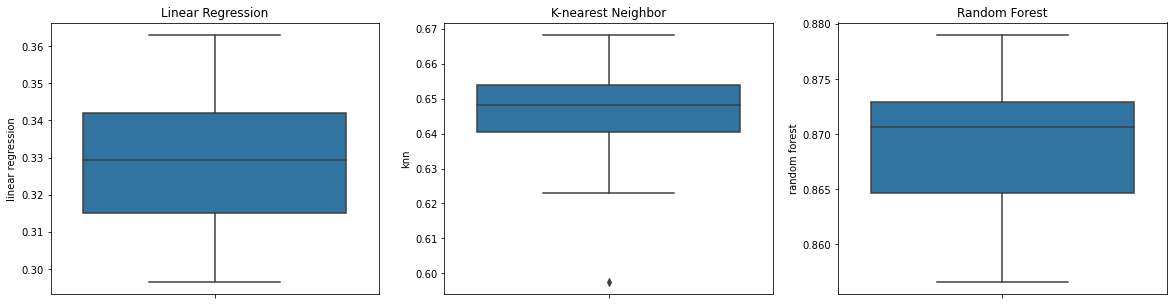

In [41]:
#Create box plots of the errors from the dfferent models
fig, (p1,p2,p3) = plt.subplots(ncols=3, figsize=(20, 5))
sns.boxplot(data=test_score_df, y="linear regression", ax=p1)
p1.set(title = "Linear Regression")
sns.boxplot(data=test_score_df, y="knn", ax=p2)
p2.set(title = "K-nearest Neighbor")
sns.boxplot(data=test_score_df, y="random forest", ax=p3)
p3.set(title = "Random Forest")

In [42]:
#Testing models without test/training splits or cross-validation
bike_LR.fit(X, y)
y_LRprediction = bike_LR.predict(X)

bike_knn.fit(X, y)
y_KNNprediction = bike_knn.predict(X)

bike_RF.fit(X, np.ravel(y))
y_RFprediction = bike_RF.predict(X)

In [43]:
# Create a data frame that displays the regression metrics
metricSummary = pd.DataFrame(columns=["Model", "MAE", "MSE", "R2"])

dictionary = {"Simple linear": y_LRprediction, "KNN": y_KNNprediction, "Random Forest": y_RFprediction}
for key in dictionary:
    metricSummary.loc[len(metricSummary.index)] = [
        key,
        metrics.mean_absolute_error(y, dictionary[key]),
        metrics.mean_squared_error(y, dictionary[key]),
        #metrics.root_mean_squared_error(y, dictionary[key]),
        metrics.r2_score(y, dictionary[key]),
    ]

# Display the metrics for the two models
metricSummary

,Model,MAE,MSE,R2
0,Simple linear,108.683952,21896.055635,0.334458
1,KNN,45.051976,4638.561701,0.859008
2,Random Forest,17.786439,762.856312,0.976813
